# 04 — Marketing & Funnel Analytics

Channel efficiency (CAC/ROAS), campaign CTR/conversion, and the site-wide purchase funnel with drop-off at each stage.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from db import get_engine

sns.set_theme(style="whitegrid")
engine = get_engine()
pd.options.display.float_format = '{:,.2f}'.format


## Purchase funnel

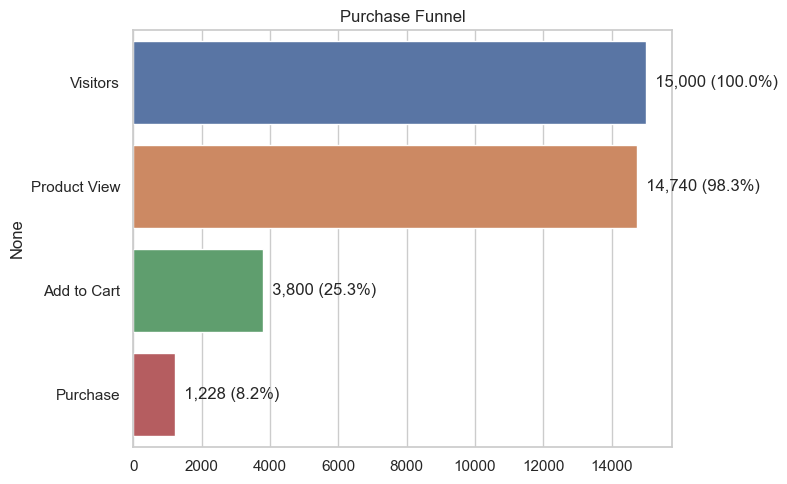

In [2]:
sessions = pd.read_sql('SELECT pages_viewed, added_to_cart, purchased FROM website_sessions', engine)
stages = {
    'Visitors': len(sessions),
    'Product View': (sessions['pages_viewed'] > 1).sum(),
    'Add to Cart': sessions['added_to_cart'].sum(),
    'Purchase': sessions['purchased'].sum(),
}
funnel = pd.Series(stages)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=funnel.values, y=funnel.index, ax=ax, hue=funnel.index, legend=False)
for i, v in enumerate(funnel.values):
    ax.text(v, i, f'  {v:,} ({v/funnel.iloc[0]*100:.1f}%)', va='center')
ax.set_title('Purchase Funnel')
plt.tight_layout()
plt.show()


## Channel comparison: CAC and ROAS

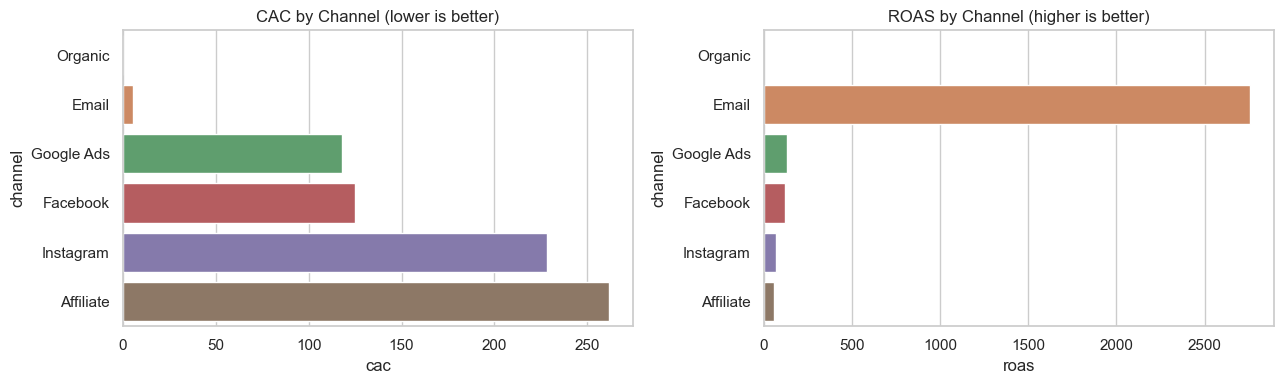

,channel,spend,conversions,cac,estimated_revenue,roas
0,Affiliate,"555,176.93",2123,261.51,"32,418,728.59",58.39
1,Email,"25,933.34",4680,5.54,"71,464,743.20","2,755.71"
2,Facebook,"356,636.69",2852,125.05,"43,550,736.67",122.12
3,Google Ads,"397,043.16",3363,118.06,"51,353,831.49",129.34
4,Instagram,"652,566.08",2857,228.41,"43,627,087.89",66.85
5,Organic,0.00,3179,0.00,"48,544,106.55",inf


In [3]:
campaigns = pd.read_sql('SELECT * FROM marketing_campaigns', engine)
aov = pd.read_sql('''
    SELECT AVG(o.quantity * p.selling_price * (1 - o.discount)) AS aov
    FROM orders o JOIN products p ON p.product_id = o.product_id
    WHERE o.order_status <> 'Cancelled'
''', engine)['aov'].iloc[0]

channel = campaigns.groupby('channel').agg(spend=('spend', 'sum'), conversions=('conversions', 'sum')).reset_index()
channel['cac'] = (channel['spend'] / channel['conversions']).round(2)
channel['estimated_revenue'] = channel['conversions'] * aov
channel['roas'] = (channel['estimated_revenue'] / channel['spend']).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=channel.sort_values('cac'), x='cac', y='channel', ax=axes[0], hue='channel', legend=False)
axes[0].set_title('CAC by Channel (lower is better)')
sns.barplot(data=channel.sort_values('roas', ascending=False), x='roas', y='channel', ax=axes[1], hue='channel', legend=False)
axes[1].set_title('ROAS by Channel (higher is better)')
plt.tight_layout()
plt.show()
channel


## Campaign CTR and conversion rate

In [4]:
campaigns['ctr_pct'] = (campaigns['clicks'] / campaigns['impressions'] * 100).round(2)
campaigns['conv_rate_pct'] = (campaigns['conversions'] / campaigns['clicks'] * 100).round(2)
campaigns[['campaign_name', 'channel', 'spend', 'ctr_pct', 'conv_rate_pct']].sort_values('conv_rate_pct', ascending=False).head(10)


,campaign_name,channel,spend,ctr_pct,conv_rate_pct
12,Google Ads Oct 2025 Push,Google Ads,"97,259.88",5.86,10.49
8,Facebook Feb 2026 Push,Facebook,"95,571.38",3.14,10.09
3,Email Jul 2026 Push,Email,"4,984.25",3.79,9.60
1,Instagram Dec 2025 Push,Instagram,"173,111.35",5.65,9.51
0,Google Ads Mar 2026 Push,Google Ads,"147,696.44",6.55,9.12
9,Email Sep 2025 Push,Email,"5,101.27",6.03,9.07
11,Organic May 2026 Push,Organic,0.00,3.27,9.05
6,Google Ads Nov 2025 Push,Google Ads,"112,320.88",3.05,8.32
17,Organic May 2026 Push,Organic,0.00,5.02,7.11
2,Facebook Nov 2025 Push,Facebook,"112,293.94",5.01,7.08
